Review Distribution by Year-Month:
year_month
2011-07      2
2011-10      2
2012-02      2
2012-06      4
2012-10      6
2013-02      6
2013-05      4
2013-09      5
2014-01      3
2014-05     17
2014-09     15
2014-12     17
2015-04     12
2015-08     27
2015-12    470
2016-04    438
2016-07    378
2016-11    350
2017-03    199
2017-07    152
2017-11    182
2018-03    185
2018-06    123
2018-10    122
2019-02    113
2019-06    135
2019-10    151
2020-01    124
2020-05     92
2020-09    117
2021-01    103
2021-05    123
2021-08    119
2021-12     80
2022-04     79
2022-08     77
2022-12     52
2023-03     38
2023-07      8
Name: count, dtype: int64


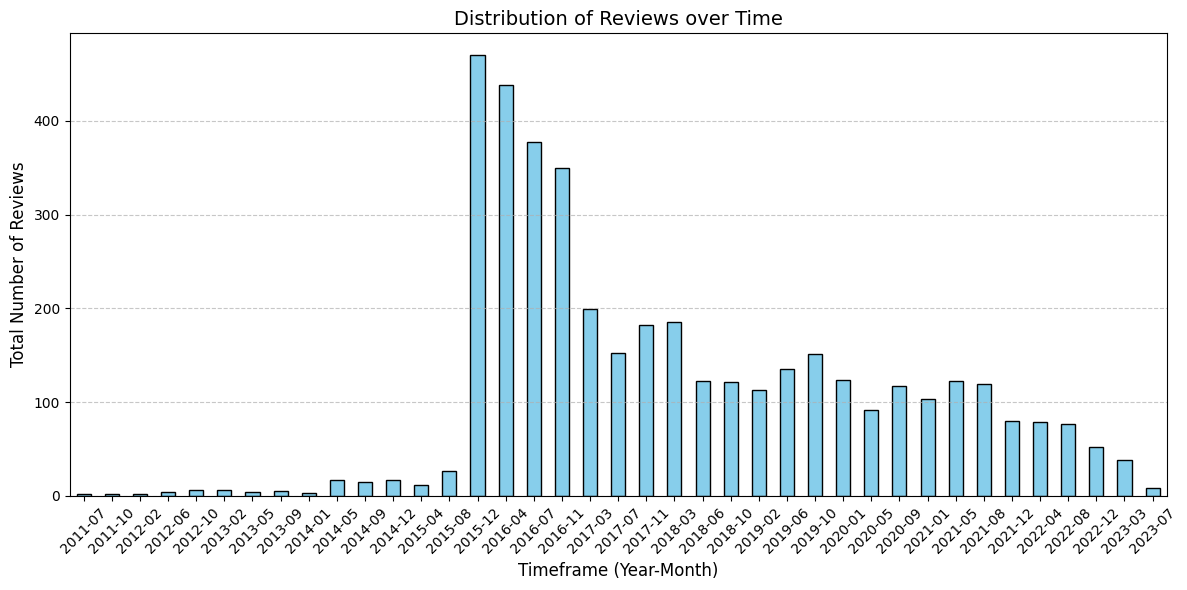

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("FusionTech_Translated_Dataset.csv")

# 2. Convert the timestamp to a readable datetime format
# The timestamps are in milliseconds (e.g., 1580000000000)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# 3. Extract Year and Month into a readable string format (YYYY-MM)
df['year_month'] = df['datetime'].dt.strftime('%Y-%m')

# 4. Calculate the distribution of reviews over the timeframes
distribution = df['year_month'].value_counts().sort_index()

# Print the readable distribution to the console
print("Review Distribution by Year-Month:")
print(distribution)

# 5. Plot the distribution
plt.figure(figsize=(12, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Reviews over Time', fontsize=14)
plt.xlabel('Timeframe (Year-Month)', fontsize=12)
plt.ylabel('Total Number of Reviews', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save or show the plot
plt.savefig('review_distribution.png')
plt.show()

/var/folders/xc/7907wjlx0h93vk1t9120tn9w0000gn/T/ipykernel_41754/910300927.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_last_24, x='rating', order=[1, 2, 3, 4, 5], palette='coolwarm_r')


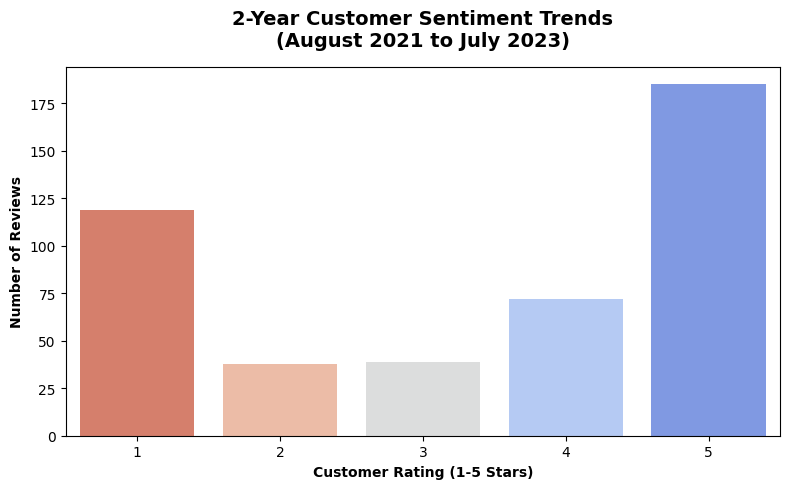

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Filter for the last 24 months (2 Years)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
max_date = df['datetime'].max()

# UPDATE: Set offset to 23 months to grab a full 24-month window including the current month
start_date = (max_date - pd.DateOffset(months=23)).replace(day=1)
df_last_24 = df[(df['datetime'] >= start_date) & (df['datetime'] <= max_date)].copy()

# Step 3: Visualize Rating Distributions
plt.figure(figsize=(8, 5))
# Using order=[1, 2, 3, 4, 5] guarantees the X-axis flows left-to-right from 1 to 5
sns.countplot(data=df_last_24, x='rating', order=[1, 2, 3, 4, 5], palette='coolwarm_r')

# --- UPDATE IS HERE ---
# Calculate string formatting for the timeframe explicitly (e.g., August 2021 to July 2023)
# %B gives the full month name (e.g., August), %b gives the abbreviated name (e.g., Aug)
timeframe_title = f'2-Year Customer Sentiment Trends\n({start_date.strftime("%B %Y")} to {max_date.strftime("%B %Y")})'

# Display the title with some extra padding and bold text so it looks clean
plt.title(timeframe_title, fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Customer Rating (1-5 Stars)', fontweight='bold')
plt.ylabel('Number of Reviews', fontweight='bold')
plt.tight_layout()

# Save or display the image
plt.show()